# Diabetes Prediction with MLflow

This notebook implements a machine learning pipeline to predict diabetes using various classification models. We'll use MLflow to track and compare model performances.

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import xgboost as xgb
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)

# Configure matplotlib
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1. Data Loading

In [4]:
# Load the dataset
df = pd.read_excel('diabetes_dataset.xlsx')

# Display first few rows
print("Dataset shape:", df.shape)
print("\nFirst 10 rows:")
df.head(10)

Dataset shape: (94, 5)

First 10 rows:


,id,Cor do cabelo,Peso,Altura,Diabético
0,1,Careca,123,185,1
1,2,Careca,109,174,0
2,3,Castanho,71,185,1
3,4,Loiro,130,166,1
4,5,Preto,93,192,0
5,6,Loiro,89,151,0
6,7,Preto,59,153,0
7,8,Loiro,94,189,1
8,9,Loiro,97,179,1
9,10,Castanho,80,141,0


## 2. Data Exploration

In [5]:
# Basic information about the dataset
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("\nDataset Statistics:")
print(df.describe())
print("\n" + "="*50)
print("\nMissing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("\nTarget Distribution:")
print(df['Diabético'].value_counts())
print(f"\nTarget Distribution (%):")
print(df['Diabético'].value_counts(normalize=True) * 100)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             94 non-null     int64 
 1   Cor do cabelo  94 non-null     object
 2   Peso           94 non-null     int64 
 3   Altura         94 non-null     int64 
 4   Diabético      94 non-null     int64 
dtypes: int64(4), object(1)
memory usage: 3.8+ KB
None


Dataset Statistics:
              id        Peso      Altura  Diabético
count  94.000000   94.000000   94.000000  94.000000
mean   47.500000   92.914894  167.734043   0.351064
std    27.279418   25.090657   17.079306   0.479862
min     1.000000   51.000000  141.000000   0.000000
25%    24.250000   71.000000  153.000000   0.000000
50%    47.500000   89.000000  166.000000   0.000000
75%    70.750000  112.750000  183.500000   1.000000
max    94.000000  140.000000  200.000000   1.000000


Missing Values:
id               0
C

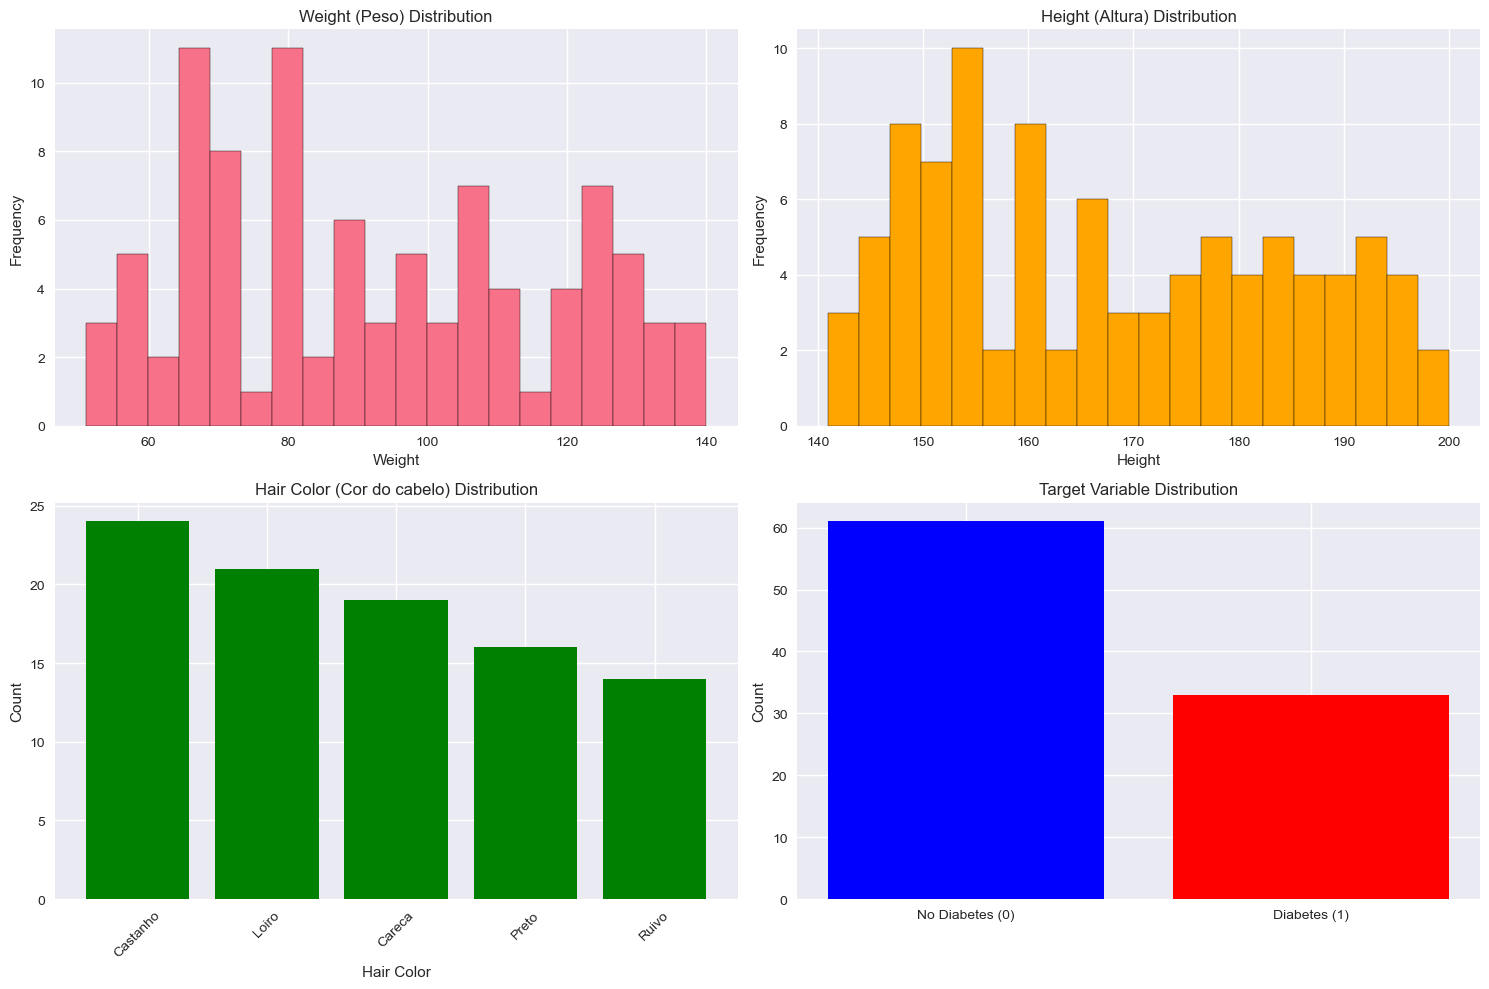

In [6]:
# Visualize data distributions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Weight distribution
axes[0, 0].hist(df['Peso'], bins=20, edgecolor='black')
axes[0, 0].set_title('Weight (Peso) Distribution')
axes[0, 0].set_xlabel('Weight')
axes[0, 0].set_ylabel('Frequency')

# Height distribution
axes[0, 1].hist(df['Altura'], bins=20, edgecolor='black', color='orange')
axes[0, 1].set_title('Height (Altura) Distribution')
axes[0, 1].set_xlabel('Height')
axes[0, 1].set_ylabel('Frequency')

# Hair color distribution
hair_counts = df['Cor do cabelo'].value_counts()
axes[1, 0].bar(hair_counts.index, hair_counts.values, color='green')
axes[1, 0].set_title('Hair Color (Cor do cabelo) Distribution')
axes[1, 0].set_xlabel('Hair Color')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Target distribution
target_counts = df['Diabético'].value_counts()
axes[1, 1].bar(['No Diabetes (0)', 'Diabetes (1)'], target_counts.values, color=['blue', 'red'])
axes[1, 1].set_title('Target Variable Distribution')
axes[1, 1].set_ylabel('Count')

plt.tight_layout()
plt.show()

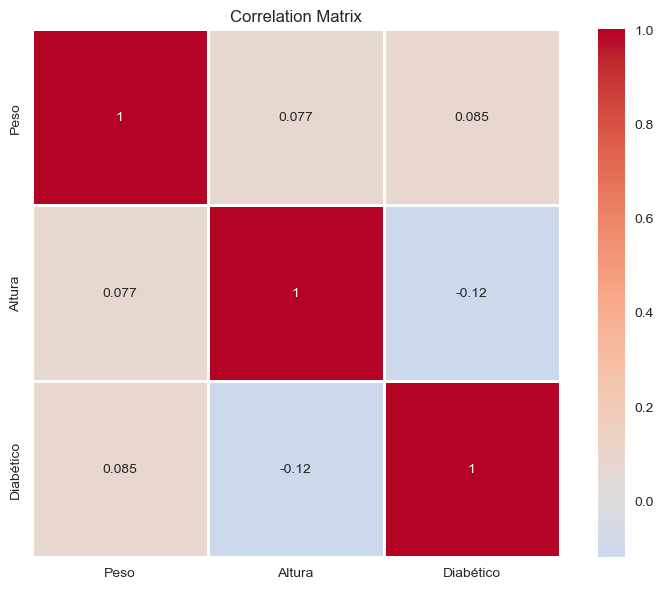

In [7]:
# Correlation analysis
# Create a copy for correlation analysis
df_numeric = df[['Peso', 'Altura', 'Diabético']].copy()

# Calculate correlation matrix
corr_matrix = df_numeric.corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## 3. Feature Engineering

In [8]:
# Create a copy of the dataframe for feature engineering
df_processed = df.copy()

# Drop the 'id' column as it's not a feature
df_processed = df_processed.drop('id', axis=1)

# Create BMI feature: BMI = Weight (kg) / (Height (cm) / 100)²
df_processed['BMI'] = df_processed['Peso'] / ((df_processed['Altura'] / 100) ** 2)

print("BMI Statistics:")
print(df_processed['BMI'].describe())
print("\nFirst few rows with BMI:")
df_processed.head()

BMI Statistics:
count    94.000000
mean     33.912742
std      11.283306
min      15.202659
25%      25.900436
50%      31.590576
75%      39.937912
max      67.973984
Name: BMI, dtype: float64

First few rows with BMI:


,Cor do cabelo,Peso,Altura,Diabético,BMI
0,Careca,123,185,1,35.938641
1,Careca,109,174,0,36.002114
2,Castanho,71,185,1,20.745069
3,Loiro,130,166,1,47.176658
4,Preto,93,192,0,25.227865


In [9]:
# Encode categorical feature 'Cor do cabelo' using one-hot encoding
df_encoded = pd.get_dummies(df_processed, columns=['Cor do cabelo'], prefix='Hair')

print("Encoded dataset shape:", df_encoded.shape)
print("\nColumn names:")
print(df_encoded.columns.tolist())
print("\nFirst few rows:")
df_encoded.head()

Encoded dataset shape: (94, 9)

Column names:
['Peso', 'Altura', 'Diabético', 'BMI', 'Hair_Careca', 'Hair_Castanho', 'Hair_Loiro', 'Hair_Preto', 'Hair_Ruivo']

First few rows:


,Peso,Altura,Diabético,BMI,Hair_Careca,Hair_Castanho,Hair_Loiro,Hair_Preto,Hair_Ruivo
0,123,185,1,35.938641,True,False,False,False,False
1,109,174,0,36.002114,True,False,False,False,False
2,71,185,1,20.745069,False,True,False,False,False
3,130,166,1,47.176658,False,False,True,False,False
4,93,192,0,25.227865,False,False,False,True,False


## 4. Data Preprocessing

In [10]:
# Separate features and target
X = df_encoded.drop('Diabético', axis=1)
y = df_encoded['Diabético']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features shape: (94, 8)
Target shape: (94,)

Feature columns:
['Peso', 'Altura', 'BMI', 'Hair_Careca', 'Hair_Castanho', 'Hair_Loiro', 'Hair_Preto', 'Hair_Ruivo']


In [11]:
# Split data into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set target distribution:")
print(y_train.value_counts())
print(f"\nTest set target distribution:")
print(y_test.value_counts())

Training set size: 75 samples
Test set size: 19 samples

Training set target distribution:
Diabético
0    49
1    26
Name: count, dtype: int64

Test set target distribution:
Diabético
0    12
1     7
Name: count, dtype: int64


In [12]:
# Scale numerical features
scaler = StandardScaler()

# Fit scaler on training data and transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame to maintain column names
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaled training data statistics:")
print(X_train_scaled.describe())

Scaled training data statistics:
               Peso        Altura           BMI  Hair_Careca  Hair_Castanho  \
count  7.500000e+01  7.500000e+01  7.500000e+01    75.000000   7.500000e+01   
mean   2.427688e-16 -4.514907e-16  2.664535e-17     0.000000  -3.478699e-17   
std    1.006734e+00  1.006734e+00  1.006734e+00     1.006734   1.006734e+00   
min   -1.634064e+00 -1.584248e+00 -1.635653e+00    -0.500000  -5.000000e-01   
25%   -8.675923e-01 -9.043133e-01 -6.597443e-01    -0.500000  -5.000000e-01   
50%   -1.011205e-01 -1.677173e-01 -1.868971e-01    -0.500000  -5.000000e-01   
75%    6.855217e-01  9.655074e-01  3.785186e-01    -0.500000  -5.000000e-01   
max    1.956251e+00  1.758765e+00  2.527212e+00     2.000000   2.000000e+00   

         Hair_Loiro  Hair_Preto    Hair_Ruivo  
count  7.500000e+01   75.000000  7.500000e+01  
mean   1.776357e-17    0.000000 -5.329071e-17  
std    1.006734e+00    1.006734  1.006734e+00  
min   -5.619515e-01   -0.500000 -4.364358e-01  
25%   -5.619515

## 5. MLflow Setup

In [13]:
# Set MLflow tracking URI (local by default)
mlflow.set_tracking_uri("file:./mlruns")

# Create or set experiment
experiment_name = "Diabetes_Prediction"
try:
    experiment_id = mlflow.create_experiment(experiment_name)
    print(f"Created new experiment: {experiment_name}")
except:
    mlflow.set_experiment(experiment_name)
    print(f"Using existing experiment: {experiment_name}")

print(f"MLflow tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment name: {experiment_name}")

Created new experiment: Diabetes_Prediction
MLflow tracking URI: file:./mlruns
Experiment name: Diabetes_Prediction


## 6. Model Training with MLflow

We'll train multiple models and track their performance using MLflow.

In [14]:
# Helper function to calculate and log metrics
def calculate_metrics(y_true, y_pred, y_pred_proba=None):
    """Calculate classification metrics"""
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_score': f1_score(y_true, y_pred, average='weighted', zero_division=0)
    }
    
    if y_pred_proba is not None:
        try:
            metrics['roc_auc'] = roc_auc_score(y_true, y_pred_proba)
        except:
            metrics['roc_auc'] = 0.0
    
    return metrics

# Helper function to log model to MLflow
def log_model_mlflow(model, model_name, params, metrics_train, metrics_test, X_test, y_test):
    """Log model, parameters, and metrics to MLflow"""
    with mlflow.start_run(run_name=model_name):
        # Log parameters
        mlflow.log_params(params)
        
        # Log training metrics
        for metric_name, metric_value in metrics_train.items():
            mlflow.log_metric(f"train_{metric_name}", metric_value)
        
        # Log test metrics
        for metric_name, metric_value in metrics_test.items():
            mlflow.log_metric(f"test_{metric_name}", metric_value)
        
        # Log model
        if isinstance(model, xgb.XGBClassifier):
            mlflow.xgboost.log_model(model, "model")
        else:
            mlflow.sklearn.log_model(model, "model")
        
        print(f"\n{model_name} - Test Metrics:")
        for metric_name, metric_value in metrics_test.items():
            print(f"  {metric_name}: {metric_value:.4f}")

### 6.1 Logistic Regression

In [15]:
# Train Logistic Regression
lr_params = {
    'C': 1.0,
    'max_iter': 1000,
    'random_state': 42
}

lr_model = LogisticRegression(**lr_params)
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_lr = lr_model.predict(X_train_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)
y_test_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
metrics_train_lr = calculate_metrics(y_train, y_train_pred_lr)
metrics_test_lr = calculate_metrics(y_test, y_test_pred_lr, y_test_pred_proba_lr)

# Log to MLflow
log_model_mlflow(lr_model, "Logistic_Regression", lr_params, metrics_train_lr, metrics_test_lr, X_test_scaled, y_test)

2026/02/28 19:31:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/28 19:31:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Logistic_Regression - Test Metrics:
  accuracy: 0.7368
  precision: 0.7395
  recall: 0.7368
  f1_score: 0.7156
  roc_auc: 0.6190


### 6.2 Random Forest Classifier

In [16]:
# Train Random Forest
rf_params = {
    'n_estimators': 100,
    'max_depth': 10,
    'min_samples_split': 5,
    'min_samples_leaf': 2,
    'random_state': 42
}

rf_model = RandomForestClassifier(**rf_params)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_rf = rf_model.predict(X_train_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)
y_test_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
metrics_train_rf = calculate_metrics(y_train, y_train_pred_rf)
metrics_test_rf = calculate_metrics(y_test, y_test_pred_rf, y_test_pred_proba_rf)

# Log to MLflow
log_model_mlflow(rf_model, "Random_Forest", rf_params, metrics_train_rf, metrics_test_rf, X_test_scaled, y_test)

2026/02/28 19:32:08 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/28 19:32:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



Random_Forest - Test Metrics:
  accuracy: 0.6316
  precision: 0.5929
  recall: 0.6316
  f1_score: 0.5610
  roc_auc: 0.3571


### 6.3 XGBoost Classifier

In [17]:
# Train XGBoost
xgb_params = {
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'eval_metric': 'logloss'
}

xgb_model = xgb.XGBClassifier(**xgb_params)
xgb_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_xgb = xgb_model.predict(X_train_scaled)
y_test_pred_xgb = xgb_model.predict(X_test_scaled)
y_test_pred_proba_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
metrics_train_xgb = calculate_metrics(y_train, y_train_pred_xgb)
metrics_test_xgb = calculate_metrics(y_test, y_test_pred_xgb, y_test_pred_proba_xgb)

# Log to MLflow
log_model_mlflow(xgb_model, "XGBoost", xgb_params, metrics_train_xgb, metrics_test_xgb, X_test_scaled, y_test)

2026/02/28 19:32:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.



XGBoost - Test Metrics:
  accuracy: 0.4211
  precision: 0.4015
  recall: 0.4211
  f1_score: 0.4104
  roc_auc: 0.3810


### 6.4 Support Vector Machine (SVM)

In [18]:
# Train SVM
svm_params = {
    'C': 1.0,
    'kernel': 'rbf',
    'gamma': 'scale',
    'random_state': 42,
    'probability': True
}

svm_model = SVC(**svm_params)
svm_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_svm = svm_model.predict(X_train_scaled)
y_test_pred_svm = svm_model.predict(X_test_scaled)
y_test_pred_proba_svm = svm_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
metrics_train_svm = calculate_metrics(y_train, y_train_pred_svm)
metrics_test_svm = calculate_metrics(y_test, y_test_pred_svm, y_test_pred_proba_svm)

# Log to MLflow
log_model_mlflow(svm_model, "SVM", svm_params, metrics_train_svm, metrics_test_svm, X_test_scaled, y_test)

2026/02/28 19:32:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/28 19:32:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



SVM - Test Metrics:
  accuracy: 0.6316
  precision: 0.5929
  recall: 0.6316
  f1_score: 0.5610
  roc_auc: 0.5476


### 6.5 K-Nearest Neighbors (KNN)

In [19]:
# Train KNN
knn_params = {
    'n_neighbors': 5,
    'weights': 'distance',
    'algorithm': 'auto'
}

knn_model = KNeighborsClassifier(**knn_params)
knn_model.fit(X_train_scaled, y_train)

# Predictions
y_train_pred_knn = knn_model.predict(X_train_scaled)
y_test_pred_knn = knn_model.predict(X_test_scaled)
y_test_pred_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics
metrics_train_knn = calculate_metrics(y_train, y_train_pred_knn)
metrics_test_knn = calculate_metrics(y_test, y_test_pred_knn, y_test_pred_proba_knn)

# Log to MLflow
log_model_mlflow(knn_model, "KNN", knn_params, metrics_train_knn, metrics_test_knn, X_test_scaled, y_test)

2026/02/28 19:32:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/28 19:32:26 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



KNN - Test Metrics:
  accuracy: 0.6316
  precision: 0.6215
  recall: 0.6316
  f1_score: 0.6248
  roc_auc: 0.4643


## 7. Model Comparison

In [20]:
# Retrieve all runs from MLflow and create comparison
from mlflow.tracking import MlflowClient

client = MlflowClient()
experiment = client.get_experiment_by_name(experiment_name)

# Get all runs
runs = client.search_runs(experiment.experiment_id, order_by=["metrics.test_roc_auc DESC"])

# Create comparison dataframe
comparison_data = []
for run in runs:
    run_data = {
        'Model': run.data.tags.get('mlflow.runName', run.info.run_id),
        'Test Accuracy': run.data.metrics.get('test_accuracy', 0),
        'Test Precision': run.data.metrics.get('test_precision', 0),
        'Test Recall': run.data.metrics.get('test_recall', 0),
        'Test F1-Score': run.data.metrics.get('test_f1_score', 0),
        'Test ROC-AUC': run.data.metrics.get('test_roc_auc', 0)
    }
    comparison_data.append(run_data)

comparison_df = pd.DataFrame(comparison_data)
print("Model Comparison (sorted by ROC-AUC):")
print(comparison_df.to_string(index=False))

Model Comparison (sorted by ROC-AUC):
Empty DataFrame
Columns: []
Index: []


KeyError: 'Model'

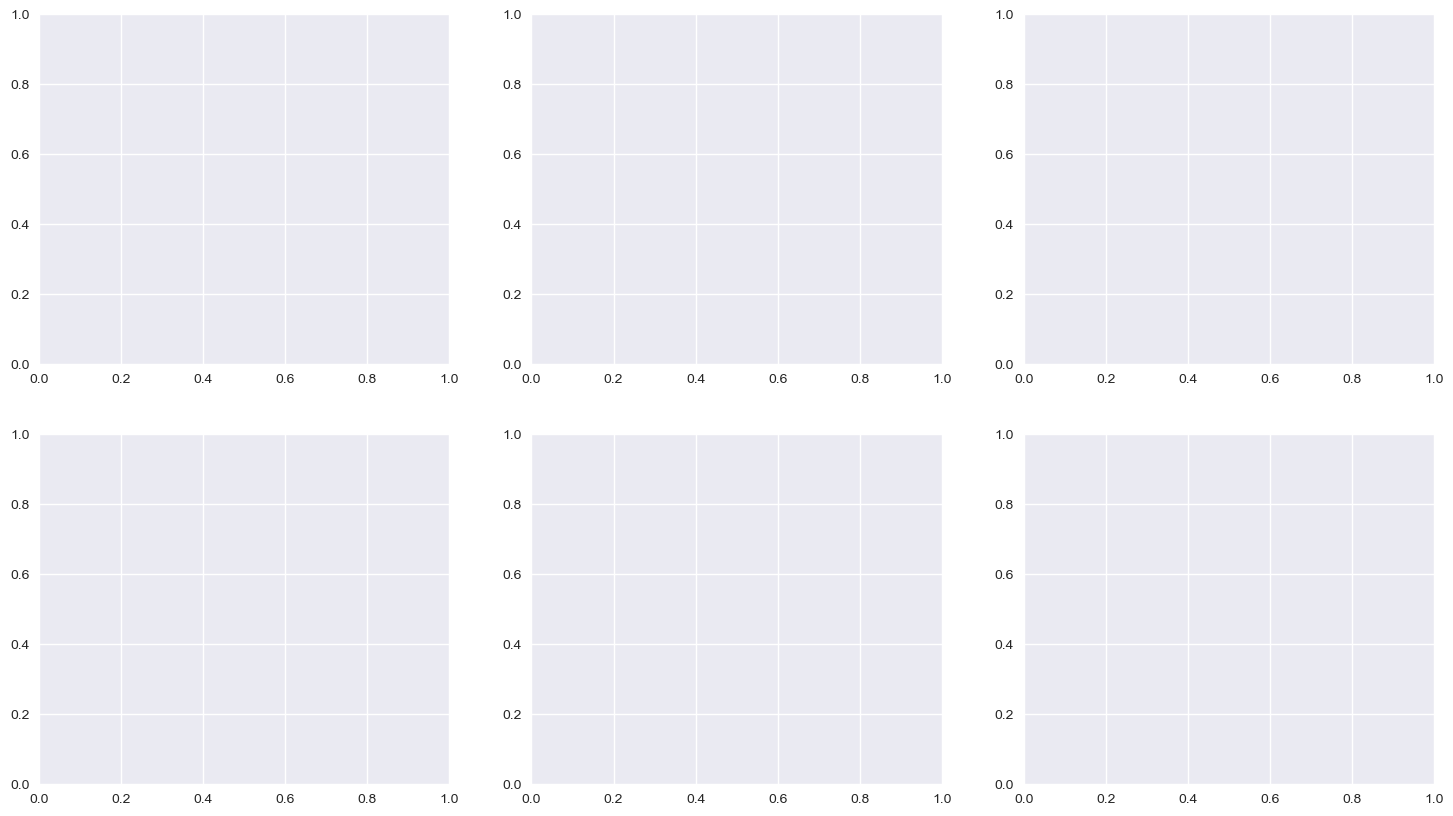

In [21]:
# Visualize metrics comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics_to_plot = ['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1-Score', 'Test ROC-AUC']
colors = ['skyblue', 'lightgreen', 'lightcoral', 'lightyellow', 'lightpink']

for idx, metric in enumerate(metrics_to_plot):
    row = idx // 3
    col = idx % 3
    
    axes[row, col].bar(comparison_df['Model'], comparison_df[metric], color=colors[idx])
    axes[row, col].set_title(metric)
    axes[row, col].set_ylabel('Score')
    axes[row, col].set_ylim([0, 1])
    axes[row, col].tick_params(axis='x', rotation=45)
    axes[row, col].grid(axis='y', alpha=0.3)

# Remove the last empty subplot
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

In [ ]:
# Create a heatmap of all metrics
metrics_matrix = comparison_df.set_index('Model')[['Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1-Score', 'Test ROC-AUC']]

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_matrix, annot=True, fmt='.4f', cmap='YlOrRd', cbar_kws={'label': 'Score'})
plt.title('Model Performance Metrics Heatmap')
plt.tight_layout()
plt.show()

## 8. Best Model Selection and Evaluation

In [ ]:
# Select best model based on ROC-AUC score
best_run = runs[0]
best_model_name = best_run.data.tags.get('mlflow.runName', best_run.info.run_id)
best_roc_auc = best_run.data.metrics.get('test_roc_auc', 0)

print(f"Best Model: {best_model_name}")
print(f"Best ROC-AUC Score: {best_roc_auc:.4f}")
print(f"\nAll metrics for best model:")
for metric_name, metric_value in best_run.data.metrics.items():
    if metric_name.startswith('test_'):
        print(f"  {metric_name}: {metric_value:.4f}")

# Load the best model
best_model_uri = f"runs:/{best_run.info.run_id}/model"

if 'XGBoost' in best_model_name:
    best_model = mlflow.xgboost.load_model(best_model_uri)
else:
    best_model = mlflow.sklearn.load_model(best_model_uri)

print(f"\nBest model loaded from: {best_model_uri}")

In [ ]:
# Get predictions from best model
if best_model_name == "Logistic_Regression":
    y_pred_best = y_test_pred_lr
    y_pred_proba_best = y_test_pred_proba_lr
elif best_model_name == "Random_Forest":
    y_pred_best = y_test_pred_rf
    y_pred_proba_best = y_test_pred_proba_rf
elif best_model_name == "XGBoost":
    y_pred_best = y_test_pred_xgb
    y_pred_proba_best = y_test_pred_proba_xgb
elif best_model_name == "SVM":
    y_pred_best = y_test_pred_svm
    y_pred_proba_best = y_test_pred_proba_svm
else:  # KNN
    y_pred_best = y_test_pred_knn
    y_pred_proba_best = y_test_pred_proba_knn

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Classification Report
print(f"\nClassification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=['No Diabetes', 'Diabetes']))

In [ ]:
# Feature importance for tree-based models
if best_model_name in ["Random_Forest", "XGBoost"]:
    if hasattr(best_model, 'feature_importances_'):
        feature_importance = pd.DataFrame({
            'Feature': X.columns,
            'Importance': best_model.feature_importances_
        }).sort_values('Importance', ascending=False)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(data=feature_importance, x='Importance', y='Feature', palette='viridis')
        plt.title(f'Feature Importance - {best_model_name}')
        plt.xlabel('Importance')
        plt.tight_layout()
        plt.show()
        
        print(f"\nFeature Importance for {best_model_name}:")
        print(feature_importance.to_string(index=False))
    else:
        print(f"\n{best_model_name} does not support feature importance visualization.")
else:
    print(f"\n{best_model_name} is not a tree-based model. Feature importance not available.")

## 9. Summary

To view all experiments in MLflow UI, run the following command in your terminal:
```
mlflow ui
```

Then open your browser and navigate to `http://localhost:5000` to see the MLflow tracking UI with all your experiments and model comparisons.